1. Place your Github API Token in .env 
2. Run github-activity-metrics-tool.py to generate your CSV file -> found in output
3. set df_users and df_repos to include the csv files generated
2. Run the following cells in order 

Import Dependencies: 

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


import CSV file
1. Generate Number Of Users -> add the users csv path
2. Generate Number Of Repos -> add the repos csv path

In [ ]:
df_users = pd.read_csv('csv')
print(f"Number of Users: {len(df_users)}")

Number of Users: 927


In [ ]:
df_repos = pd.read_csv('csv')
print(f"Number of Repos: {len(df_repos)}")

Number of Repos: 2608


In [11]:
# Sort repos by stargazers_count in descending order
top_starred_repos = df_repos.sort_values(by="stargazers_count", ascending=False)

# select needed columns
top_starred_repos = top_starred_repos[["full_name", "stargazers_count", "language"]]

# Display the top 10
print("Top 20 Most Starred Repos:")
print(top_starred_repos.head(20).to_string(index=False))


Top 20 Most Starred Repos:
                                                                                                            full_name  stargazers_count         language
                                                                                   synercys/annotated_latex_equations              3880              TeX
                                                                  jphall663/awesome-machine-learning-interpretability              3869              NaN
                                                                                             DrWaleedAYousef/Teaching              1017      Mathematica
                                                                                                  GWUDCAP/cc-sessions               848           Python
                                                                 jphall663/interpretable_machine_learning_with_python               682 Jupyter Notebook
                                                       

In [12]:
# Count number of repos per license type + try to include ones that dont 
license_counts = df_repos["license"].value_counts().reset_index()
license_counts.columns = ["license", "count"]

print("Most Common Licenses:")
print(license_counts.head(10).to_string(index=False))

Most Common Licenses:
                                       license  count
                                   MIT License    360
                            Apache License 2.0    116
                                         Other     88
               GNU General Public License v3.0     70
       BSD 3-Clause "New" or "Revised" License     25
          Creative Commons Zero v1.0 Universal     19
Creative Commons Attribution 4.0 International     10
             BSD 2-Clause "Simplified" License      7
               GNU General Public License v2.0      7
        GNU Affero General Public License v3.0      7


In [13]:
#How many users are students,postdoc,faculty, alum, and how many are unique

# find all unique categories
unique_roles = df_users["predicted general George Washington University connection/role"].unique()
print("Unique Roles in GWU File:")
print(unique_roles)

# Count number of users in each category
role_count = df_users["predicted general George Washington University connection/role"].value_counts()

print("\n Number of Users in Each Category :")
print(role_count)



Unique Roles in GWU File:
[nan 'Student' 'Faculty' 'Alum' 'GWU bootcamp student' 'Postdoc']

 Number of Users in Each Category :
predicted general George Washington University connection/role
Student                 273
Faculty                  32
Alum                     32
GWU bootcamp student     17
Postdoc                   2
Name: count, dtype: int64


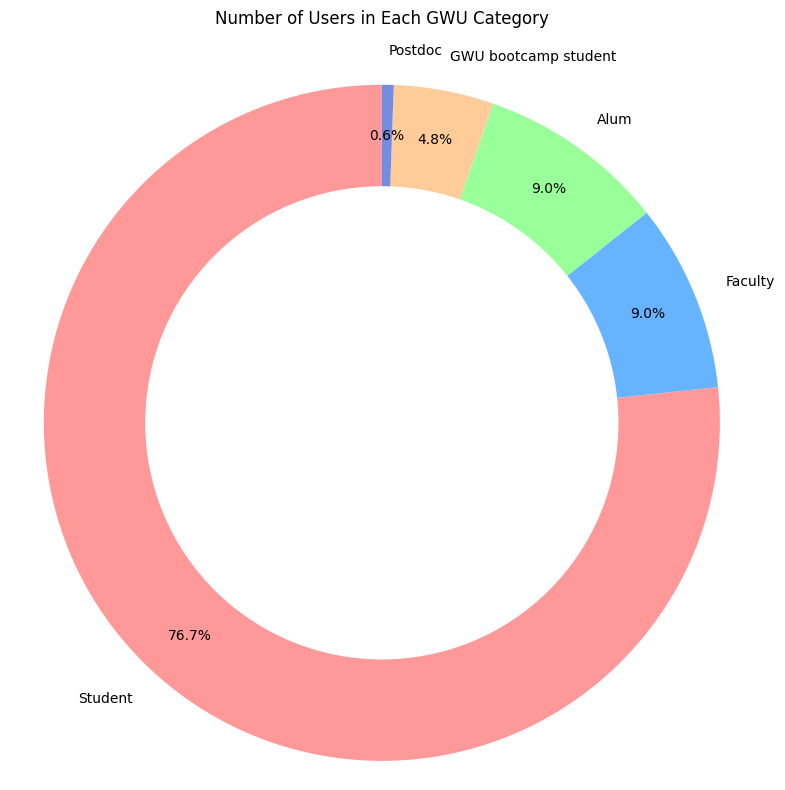

In [14]:
# Pie chart of the number of users in each category + generate lsit of popular alum
sizes = role_count.values
labels = role_count.index

#colors
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99',"#748de0" ]
 

fig1, ax = plt.subplots(figsize=(8,8))
ax.pie(sizes, colors = colors[:len(sizes)], labels=labels, autopct='%1.1f%%', startangle=90, pctdistance= 0.85)

#draw circle
centre_circle = plt.Circle((0,0),0.70,fc='white')
ax.add_artist(centre_circle)

# Equal aspect ratio ensures that pie is drawn as a circle
ax.axis('equal')  
plt.title("Number of Users in Each GWU Category", pad = 30)
plt.tight_layout()
plt.show()


In [15]:
#displaying percentage of users who were not categorized
total = len(df_users)
uncat = df_users["predicted general George Washington University connection/role"].isna().sum()
percent = round ((uncat / total) * 100,2)

print(f"Uncategorized: {uncat} users ({percent}%) out of {total}")

Uncategorized: 571 users (61.6%) out of 927


In [16]:
# Sort users by repos in descending order
top_users_repos = df_users.sort_values(by="public_repos", ascending=False)

# select needed columns
top_users_repos = top_users_repos[["name", "public_repos"]]

# Display the top 10
print("Top 10 Users by Number of Public Repos:")
print(top_users_repos.head(10).to_string(index=False))

Top 10 Users by Number of Public Repos:
                                                              name  public_repos
Professor Ernesto C.R., George Washington University (Www.Gwu.Edu)           217
                                        Ada - Gwu Joint Ms Program           209
                              Gw Libraries And Academic Innovation           205
                                                            Gwu Os           159
                                                          Yangzhou           138
                                                              Kwaw           128
                                   Flight Dynamics And Control Lab           121
                                                     Marck Vaisman           118
                                                     George Stoica           108
                                                    John Helveston            98


In [17]:
#How many users are undergrads,grads,and phd

# find all unique categories
# unique_roles = df_users["additional predicted info"].unique()
# print("Unique Roles in GWU File:")
# print(unique_roles)

# Count number of users in each category
role_count = df_users["additional predicted info"].value_counts()

print("\n Number of Users by Degree:")
print(role_count)




 Number of Users by Degree:
additional predicted info
Graduate student         76
Doctoral student         55
Undergraduate student    16
Name: count, dtype: int64


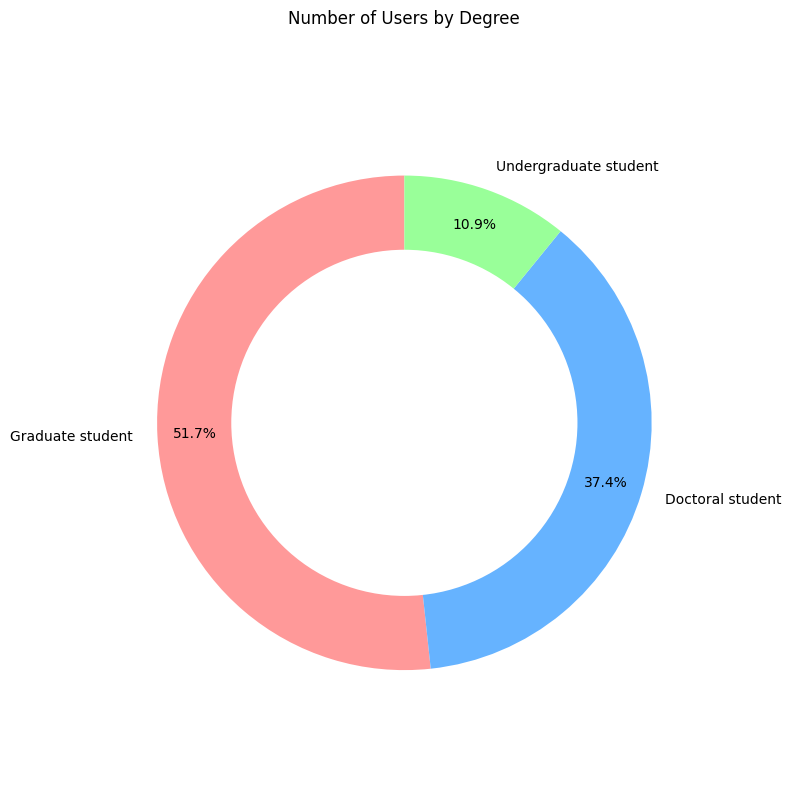

In [33]:
# Pie chart of the number of users by additional predicted indo
sizes = role_count.values
labels = role_count.index

#colors
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99',"#748de0" ]
 

fig1, ax = plt.subplots(figsize=(8,8))
ax.pie(sizes, colors = colors[:len(sizes)], labels=labels, autopct='%1.1f%%', startangle=90, pctdistance= 0.85)

#draw circle
centre_circle = plt.Circle((0,0),0.70,fc='white')
ax.add_artist(centre_circle)

# Equal aspect ratio ensures that pie is drawn as a circle
ax.axis('equal')  
plt.title("Number of Users by Degree", pad = 30)
plt.tight_layout()
plt.show()

In [19]:
#displaying percentage of users who were not categorized
total = len(df_users)
uncat = df_users["additional predicted info"].isna().sum()
percent = round ((uncat / total) * 100,2)

print(f"Uncategorized: {uncat} users ({percent}%) out of {total}")

Uncategorized: 780 users (84.14%) out of 927


In [34]:
# Convert updated_at to datetime
df_repos["updated_at"] = pd.to_datetime(df_repos["updated_at"])

# Sort by most recently updated repos
recent_repos = df_repos.sort_values(by="updated_at", ascending=False)

# Show top 10 most recently updated repos
print("Top 10 Most Recently Updated Repos:")
print(recent_repos[["full_name", "updated_at", "language"]].head(10).to_string(index=False))

Top 10 Most Recently Updated Repos:
                               full_name                updated_at    language
               GehnaAhuja/embedder-agent 2025-09-24 16:25:47+00:00         NaN
              ujjawal40/fall-2025-group3 2025-09-24 15:56:50+00:00         TeX
                     GWUDCAP/cc-sessions 2025-09-24 15:50:36+00:00      Python
    gwuniversity/GWUniversity-SelfInvite 2025-09-24 15:49:55+00:00         NaN
    gwuniversity/GWUniversity-SelfInvite 2025-09-24 15:49:55+00:00         NaN
                DrWaleedAYousef/Teaching 2025-09-24 13:55:02+00:00 Mathematica
                  iHeartGraph/PicoDomain 2025-09-24 09:28:51+00:00         NaN
       Taslim-M/Unsupervised-Elicitation 2025-09-24 08:25:11+00:00      Python
GWU-CSCI-2410/submission-server-tutorial 2025-09-24 03:13:56+00:00         NaN
                  fdcl-gwu/aruco-markers 2025-09-24 01:57:21+00:00         C++


In [35]:
# Filter repos without a license
no_license = df_repos[df_repos["license"].isna()]

# Sort them by stargazers_count (most popular first)
popular_no_license = no_license.sort_values(by="stargazers_count", ascending=False)

# Show top 20 most popular repos without licenses
print("Top 20 Most Popular Repos Without Licenses:")
print(popular_no_license[["full_name", "stargazers_count", "language"]].head(20).to_string(index=False))


Top 20 Most Popular Repos Without Licenses:
                                                                                                            full_name  stargazers_count         language
                                                                                                  GWUDCAP/cc-sessions               848           Python
                                                                 jphall663/interpretable_machine_learning_with_python               682 Jupyter Notebook
                                                                                            jphall663/GWU_data_mining               240 Jupyter Notebook
                                                                                     juanklopper/JuliaCourseNotebooks               235 Jupyter Notebook
                                                                                                  gwsystems/composite               191                C
                                      

In [36]:
# Sort users by followers in descending order
top_alumni = df_users[df_users["predicted general George Washington University connection/role"].str.lower() == "alum"]
top_alumni = top_alumni.sort_values(by="followers", ascending=False)

# Select needed columns
top_alumni_list = top_alumni[["name", "followers"]]

# Display the top 10 most popular alumni
print("Top 10 Most Popular Alumni by Followers:")
print(top_alumni_list.head(10).to_string(index=False))

Top 10 Most Popular Alumni by Followers:
                    name  followers
            Grady Mcpeak         34
           Seamus Malley         25
Armando Herrera Canelon          21
         Cameron Parvini         11
              Paul Kelly         11
             Daniel Mace          9
               Ed Sivick          9
           Ankush Wadhwa          6
                   Jacob          6
                   Asrvn          5


In [24]:
# Sort users by followers in descending order
top_users_followers = df_users.sort_values(by="followers", ascending=False)

# Select needed columns
top_users_followers = top_users_followers[["name", "followers"]]

# Display the top 10 users by number of followers
print("Top 10 Users by Number of Followers:")
print(top_users_followers.head(10).to_string(index=False))

Top 10 Users by Number of Followers:
                            name  followers
                       Gwuhaolin       2883
Waleed A. Yousef (Waleed Yousef)       1634
                             Ph_        739
                Dr Jay H Klopper        320
                            Kwaw        267
                  John Helveston        180
                    Yuxiao Huang        153
                   Marck Vaisman        123
                         Gang Wu        110
             Systems Programming        106


In [25]:
# Display the top 10 users by number of public repositories
print("Top 10 Users by Number of Public Repos:")
print(top_users_repos.head(10).to_string(index=False))

Top 10 Users by Number of Public Repos:
                                                              name  public_repos
Professor Ernesto C.R., George Washington University (Www.Gwu.Edu)           217
                                        Ada - Gwu Joint Ms Program           209
                              Gw Libraries And Academic Innovation           205
                                                            Gwu Os           159
                                                          Yangzhou           138
                                                              Kwaw           128
                                   Flight Dynamics And Control Lab           121
                                                     Marck Vaisman           118
                                                     George Stoica           108
                                                    John Helveston            98


In [45]:
# Sort users by followers in descending order
top_labs = df_users[df_users["additional predicted info"].str.lower() == "GWU Research Laboratory"]
top_labs = top_labs.sort_values(by="followers", ascending=False)

# Select needed columns
top_labs_list = top_labs[["name", "followers"]]

# Display the top 10 most popular alumni
print("Top 10 Most Popular Labs by Followers:")
print(top_labs_list.head(10).to_string(index=False))

Top 10 Most Popular Labs by Followers:
Empty DataFrame
Columns: [name, followers]
Index: []
